# GRU for IoT Intrusion Detection — TPU v5e Single-Model Notebook

Single-model training notebook generated from the v14 paper-faithful notebook.
Selected model: **GRU**
**Base:** `lstm_cnn_iot_v8_verified` → **v14 TPU-accelerated paper-faithful** (Sinha et al., 2025)

### Goal of this notebook
This version keeps the **paper’s core methodological choices** intact while using **TPU/JAX acceleration** to fit Colab hardware limits:

- **Hybrid LSTM-CNN** core architecture only
- **No extra attention block**
- same **BoT-IoT** workflow
- **70 / 15 / 15** split
- **Min-Max scaling**
- **one-hot encoding**
- **SMOTE + random undersampling**
- **dropout + L2 + early stopping**
- **SHAP-based interpretation**
- **TPU/JAX + `bfloat16`** only as execution-level acceleration

### Why this version exists
The earlier TPU-stable notebook fixed Colab TPU runtime crashes, but it still carried an added attention block from the earlier notebook lineage. That makes the run less defensible as a replication.

This notebook keeps the TPU stability fixes while removing architecture changes that are not needed for a paper-faithful reproduction.

### TPU/runtime fixes preserved
| # | Fix | Purpose |
|---|-----|---------|
| T1 | **JAX-backend Keras only** | avoids PJRT/libtpu conflicts on Colab TPU |
| T2 | **No `jax.distributed.initialize()`** | avoids single-host TPU process-state crashes |
| T3 | **No TensorFlow in TPU execution path** | prevents TPU runtime ownership conflicts |
| T4 | **All models built inside `strategy.scope()`** | consistent TPU/JAX object creation |
| T5 | **`bfloat16` mixed precision** | native TPU acceleration |
| T6 | **`sample_weight` instead of TPU-incompatible `class_weight`** | stable weighted fitting |
| T7 | **checkpoint + reload** | resumable long runs |
| T8 | **CPU-rebuilt SHAP model** | SHAP compatibility |

In [ ]:
# CELL 1: Install Dependencies
# NOTE:
# - Do NOT install TensorFlow on Colab TPU v5e for this notebook.
# - The TPU path below uses Keras 3 + JAX only.
# - Mixing TF TPU runtime pieces with JAX/libtpu on this runtime can trigger
#   PJRT / XLA process-state crashes and kernel restarts.
%pip install -q numpy pandas scikit-learn scipy keras matplotlib seaborn imbalanced-learn pyyaml kaggle joblib tqdm shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 43.0 MB/s eta 0:00:00


In [ ]:
# CELL 1b: Hugepages — now handled inline in Cell 2 (before TF import).
# This cell is kept as a placeholder to preserve cell numbering.
# You may delete it; it has no effect.
print('Cell 1b: hugepages are set in Cell 2 before TF import — nothing to do here.')

Cell 1b: hugepages are set in Cell 2 before TF import — nothing to do here.


In [ ]:
# CELL 2: TPU v5e-1 Setup — JAX-backend Keras (stable)
# ─────────────────────────────────────────────────────────────────────────────
# WHY v9 crashed:
#   The uploaded runtime logs show repeated:
#     F ... pjrt_c_api_wrapper_impl.cc:514] Unexpected PJRT_ProcessState ...
#   followed by a kernel restart. On Colab TPU v5e this commonly happens when
#   multiple runtime stacks try to manage libtpu / PJRT state at once.
#
# STABILITY PATCH (v10):
#   1. Use Keras 3 with JAX backend only.
#   2. Do NOT call jax.distributed.initialize() on single-host Colab TPU.
#   3. Do NOT import TensorFlow / tf.data in the TPU execution path.
#   4. Feed NumPy arrays directly to Keras/JAX.
#
# IMPORT ORDER (must be exact):
#   1. set KERAS_BACKEND=jax
#   2. import jax
#   3. import keras
import os
import warnings
import contextlib

# Must be set before importing keras
os.environ['KERAS_BACKEND'] = 'jax'
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

warnings.filterwarnings(
    'ignore',
    message=r'.*[Tt]ransparent hugepages.*',
    category=UserWarning,
)

import jax

# IMPORTANT:
# Single-host Colab TPU v5e should NOT call jax.distributed.initialize().
# The uploaded logs show PJRT process-state crashes consistent with that path.
_jax_devs = jax.devices()
print(f'JAX devices      : {_jax_devs}')
_on_tpu_jax = any(d.platform == 'tpu' for d in _jax_devs)
if not _on_tpu_jax:
    print('WARNING: JAX sees no TPU. Go to Runtime → Change runtime type → TPU v5e-1')
    print('         then Runtime → Disconnect and delete runtime, and reconnect.')

import keras
print(f'Keras backend    : {keras.backend.backend()}')
assert keras.backend.backend() == 'jax', (
    f"Expected keras backend 'jax', got '{keras.backend.backend()}'. "
    "Ensure os.environ['KERAS_BACKEND']='jax' is set before the first keras import."
)

class _JAXTPUStrategy:
    """Drop-in shim replacing tf.distribute.TPUStrategy for JAX-backend Keras."""
    @property
    def num_replicas_in_sync(self):
        return jax.device_count()

    @contextlib.contextmanager
    def scope(self):
        yield

strategy = _JAXTPUStrategy()
N_CORES  = strategy.num_replicas_in_sync
ON_TPU   = _on_tpu_jax
print(f'N_CORES          : {N_CORES}')

if N_CORES == 1:
    print('Confirmed        : single-chip v5e-1 (1 TensorCore, 1 JAX device)')
elif N_CORES == 4:
    print('Confirmed        : v5e-4 (2x2 slice, ct5lp-hightpu-4t)')
elif N_CORES == 8:
    print('Confirmed        : v5e-8 (2x4 slice, ct5lp-hightpu-8t)')
else:
    print(f'WARNING          : unexpected N_CORES={N_CORES} for v5e')

PRECISION_POLICY = 'mixed_bfloat16' if ON_TPU else 'mixed_float16'
keras.mixed_precision.set_global_policy(PRECISION_POLICY)
pol = keras.mixed_precision.global_policy()
print(f'Precision policy : {pol.name}')
print(f'Compute dtype    : {pol.compute_dtype}')
print(f'Variable dtype   : {pol.variable_dtype}')

BATCH_SIZE_PER_CORE = 128   # matches paper Table 4
GLOBAL_BATCH_SIZE   = BATCH_SIZE_PER_CORE * max(1, N_CORES)
print(f'Global batch size: {GLOBAL_BATCH_SIZE} ({BATCH_SIZE_PER_CORE} × {max(1, N_CORES)} cores)')


JAX devices      : [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]
Keras backend    : jax
N_CORES          : 1
Confirmed        : single-chip v5e-1 (1 TensorCore, 1 JAX device)
Precision policy : mixed_bfloat16
Compute dtype    : bfloat16
Variable dtype   : float32
Global batch size: 128 (128 × 1 cores)


In [ ]:
# =========================
# CELL A — RUN OUTPUT SETUP
# Place after imports, before training
# =========================

import os
import re
import sys
import json
import shutil
import platform
from datetime import datetime

# ---- SET THIS PER NOTEBOOK ----
# Hybrid notebook   -> "LSTM-CNN (Hybrid)"
# CNN notebook      -> "CNN"
# RNN notebook      -> "RNN"
# LSTM notebook     -> "LSTM"
# BiLSTM notebook   -> "BiLSTM"
# GRU notebook      -> "GRU"
MODEL_NAME = "GRU"

def slugify(text: str) -> str:
    text = text.strip().lower()
    text = re.sub(r'[^a-z0-9]+', '_', text)
    return text.strip('_')

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_SLUG = slugify(MODEL_NAME)

RUN_DIR = os.path.join("results", MODEL_SLUG, RUN_TS)
ARTIFACT_DIR = os.path.join(RUN_DIR, "artifacts")
FIG_DIR = os.path.join(RUN_DIR, "figures")

os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("MODEL_NAME :", MODEL_NAME)
print("RUN_DIR    :", RUN_DIR)
print("ARTIFACTS  :", ARTIFACT_DIR)
print("FIGURES    :", FIG_DIR)

MODEL_NAME : GRU
RUN_DIR    : results/gru/20260401_061855
ARTIFACTS  : results/gru/20260401_061855/artifacts
FIGURES    : results/gru/20260401_061855/figures


In [ ]:
# CELL 3: Kaggle Credentials and Dataset Download
import glob

os.environ['KAGGLE_USERNAME'] = 'kruinfosec'   # <-- replace
os.environ['KAGGLE_KEY']      = '0595034e9978007f27bea6c159f47f24'    # <-- replace

DATA_DIR = 'data/raw'
os.makedirs(DATA_DIR, exist_ok=True)

if not glob.glob(os.path.join(DATA_DIR, '**/*.csv'), recursive=True):
    print('Downloading BoT-IoT dataset from Kaggle...')
    !kaggle datasets download -d majedjaber/bot-iot-all-features-5-sample -p {DATA_DIR} --unzip
else:
    n = len(glob.glob(os.path.join(DATA_DIR, '**/*.csv'), recursive=True))
    print(f'Dataset already present ({n} CSV files)')

Dataset URL: https://www.kaggle.com/datasets/majedjaber/bot-iot-all-features-5-sample
License(s): unknown
100% 54.4M/54.4M [00:00<00:00, 149MB/s]



In [ ]:
# CELL 4: Load Data
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, '**/*.csv'), recursive=True))
print(f'Loading {len(csv_files)} CSV file(s)...')
df = pd.concat([pd.read_csv(f, low_memory=False) for f in csv_files], ignore_index=True)
print(f'Total records: {len(df):,}  |  Columns: {len(df.columns)}')

# H3: full dataset required for paper targets
SAMPLE_FRAC = 1.0
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    print(f'Sampled to {len(df):,} records ({SAMPLE_FRAC*100:.0f}%)')
else:
    print(f'Using full dataset: {len(df):,} records')

Loading 4 CSV file(s)...
Total records: 3,668,522  |  Columns: 46
Using full dataset: 3,668,522 records


In [ ]:
# CELL 5: Clean and Encode
df = df.replace([np.inf, -np.inf], np.nan).drop_duplicates()
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
            df[col] = df[col].fillna(df[col].mean())
        else:
            df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'unknown')
print(f'After cleaning: {len(df):,} records')

# Target column: 'category' (5-class, per paper Figure 7)
target_col = None
for candidate in ['category', 'Category', 'label', 'Label', 'attack', 'Attack']:
    if candidate in df.columns:
        target_col = candidate
        break
if target_col is None:
    print('WARNING: could not auto-detect target.')
    print(df.columns.tolist())
    target_col = input('Enter target column name: ')
print(f'Target: {target_col}'); print(df[target_col].value_counts())

exclude_cols = {target_col}
for col in df.columns:
    if col.lower() in ['pkseqid','saddr','daddr','sport','dport',
                       'subcategory','label','attack'] and col != target_col:
        exclude_cols.add(col)

cat_cols = [c for c in df.select_dtypes(include=['object','category']).columns
            if c not in exclude_cols]
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
    print(f'One-hot encoded {len(cat_cols)} cols. Total features: {len(df.columns)}')

feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols].values.astype(np.float32)
le = LabelEncoder()
y  = le.fit_transform(df[target_col])
print(f'Classes: {dict(zip(le.classes_, range(len(le.classes_))))}  |  X: {X.shape}')

N_CLASSES = len(np.unique(y))
IS_BINARY = (N_CLASSES == 2)
print(f'Task: {"Binary" if IS_BINARY else "Multiclass"} ({N_CLASSES} classes)')

After cleaning: 3,668,522 records
Target: category
category
DDoS              1926624
DoS               1650260
Reconnaissance      91082
Normal                477
Theft                  79
Name: count, dtype: int64
One-hot encoded 3 cols. Total features: 68
Classes: {'DDoS': 0, 'DoS': 1, 'Normal': 2, 'Reconnaissance': 3, 'Theft': 4}  |  X: (3668522, 60)
Task: Multiclass (5 classes)


In [ ]:
# CELL 6: Split → Scale → PCA → SMOTE (train only) + sample_weight fix
#
# T2/T3 FIX: v8 divergence root cause + T6 preparation
# ─────────────────────────────────────────────────────
# v8 applied SMOTE to training then evaluated on natural val.
# The natural val set is 99.97% attack (only 24 Normal + 4 Theft samples).
# Any model that correctly predicts minority classes looks like it has
# ~0% accuracy on val because accuracy counts those predictions as errors.
#
# Fix: create val_sample_weight mirroring CLASS_WEIGHT so that val loss and
# accuracy are computed with balanced importance — the same weighting that
# training sees. This makes val_loss/val_accuracy track training meaningfully.
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# 70/15/15 split — stratified
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f'Split: Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}')

# MinMax scaling — fit on train only
scaler  = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# PCA — fit on train only; guard for MaxPool minimum
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

pca     = PCA(n_components=0.95, random_state=42)
X_train = pca.fit_transform(X_train_scaled)
X_val   = pca.transform(X_val_scaled)
X_test  = pca.transform(X_test_scaled)
print(f'PCA components: {X_train.shape[1]}')

MIN_COMPONENTS = 8
if X_train.shape[1] < MIN_COMPONENTS:
    n_comp = min(MIN_COMPONENTS, X_train_scaled.shape[1])
    pca    = PCA(n_components=n_comp, random_state=42)
    X_train = pca.fit_transform(X_train_scaled)
    X_val   = pca.transform(X_val_scaled)
    X_test  = pca.transform(X_test_scaled)
    print(f'PCA overridden to {n_comp} components')

# SMOTE + RandomUnderSampler on TRAIN ONLY
print(f'Before SMOTE: {dict(pd.Series(y_train).value_counts())}')
smote_pipeline = ImbPipeline([
    ('smote',       SMOTE(random_state=42)),
    ('undersample', RandomUnderSampler(random_state=42))
])
X_train, y_train = smote_pipeline.fit_resample(X_train, y_train)
print(f'After SMOTE+undersample: {dict(pd.Series(y_train).value_counts())}')

# Class weights (balanced) — used for train sample_weight AND val_sample_weight
cw_values    = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
CLASS_WEIGHT = dict(enumerate(cw_values))
print(f'Class weights: {CLASS_WEIGHT}')

# T3 FIX: compute val and test sample weights from the natural label distribution
# This makes validation loss comparable to training loss so EarlyStopping works.
def make_sample_weight(y_labels, class_weight_dict):
    return np.array([class_weight_dict[c] for c in y_labels], dtype=np.float32)

sw_train = make_sample_weight(y_train, CLASS_WEIGHT)
sw_val   = make_sample_weight(y_val,   CLASS_WEIGHT)

# Reshape to 3-D for DL models
X_train_dl = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_dl   = X_val.reshape((X_val.shape[0],     X_val.shape[1],   1))
X_test_dl  = X_test.reshape((X_test.shape[0],   X_test.shape[1],  1))
print(f'DL input shape: {X_train_dl.shape}')

Split: Train=2,567,965 | Val=550,278 | Test=550,279
PCA components: 7
PCA overridden to 8 components
Before SMOTE: {0: np.int64(1348637), 1: np.int64(1155182), 3: np.int64(63757), 2: np.int64(334), 4: np.int64(55)}
After SMOTE+undersample: {0: np.int64(1348637), 1: np.int64(1348637), 2: np.int64(1348637), 3: np.int64(1348637), 4: np.int64(1348637)}
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}
DL input shape: (6743185, 8, 1)


In [ ]:
# CELL 7: Model Builders — built inside strategy.scope()
#
# Paper-faithful TPU edition:
# - v14 serialization patch: register LastTimestep so custom-layer configs are loadable.
# - Keep the core Hybrid LSTM-CNN only.
# - Remove the extra attention block from the earlier notebook lineage.
# - Preserve TPU-safe training fixes, bfloat16 output safety, LastTimestep,
#   MaxPool padding='same', L2, clipnorm, and explicit cosine-decay steps.
from keras import layers, models, regularizers

INPUT_SHAPE = (X_train_dl.shape[1], X_train_dl.shape[2])
N_OUT   = 1 if IS_BINARY else N_CLASSES
LOSS    = 'binary_crossentropy' if IS_BINARY else 'sparse_categorical_crossentropy'
OUT_ACT = 'sigmoid' if IS_BINARY else 'softmax'

@keras.saving.register_keras_serializable(package='Custom')
class LastTimestep(keras.layers.Layer):
    """Returns the last timestep of a sequence: (B, T, F) → (B, F)."""
    def call(self, x):
        return x[:, -1, :]
    def get_config(self):
        return super().get_config()

    @classmethod
    def from_config(cls, config):
        return cls(**config)

def cosine_decay(lr, total_steps):
    return keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=lr,
        decay_steps=max(1, total_steps),
        alpha=1e-6
    )

LSTM2_UNITS = 128

def build_lstm_cnn(input_shape, total_steps):
    inp = layers.Input(shape=input_shape)
    x   = inp

    # LSTM block — temporal feature extraction
    x = layers.LSTM(
        256, activation='tanh', return_sequences=True,
        kernel_regularizer=regularizers.l2(1e-4), name='lstm_1'
    )(x)
    x = layers.Dropout(0.3, name='lstm_drop_1')(x)
    x = layers.LSTM(
        LSTM2_UNITS, activation='tanh', return_sequences=True,
        kernel_regularizer=regularizers.l2(1e-4), name='lstm_2'
    )(x)
    x = layers.Dropout(0.3, name='lstm_drop_2')(x)

    # Paper-faithful path:
    # no extra attention block; go directly from sequential features to CNN stage.
    x = LastTimestep(name='seq_last')(x)
    x = layers.Reshape((LSTM2_UNITS, 1), name='reshape_for_cnn')(x)

    # CNN block — spatial feature extraction
    for filters, tag in zip([64, 128, 256], ['1','2','3']):
        x = layers.Conv1D(filters, 3, activation='relu', padding='same', name=f'conv_{tag}')(x)
        x = layers.MaxPooling1D(pool_size=2, padding='same', name=f'pool_{tag}')(x)

    x   = layers.Flatten(name='flatten')(x)
    x   = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4), name='dense_1'
    )(x)
    x   = layers.Dropout(0.3, name='dense_drop')(x)
    out = layers.Dense(N_OUT, activation=OUT_ACT, dtype='float32', name='output')(x)

    m = models.Model(inp, out, name='LSTM_CNN_Hybrid')
    m.compile(
        optimizer=keras.optimizers.Adam(
            cosine_decay(0.0005, total_steps), clipnorm=1.0
        ),
        loss=LOSS,
        metrics=['accuracy']
    )
    return m

def build_cnn(input_shape, total_steps):
    inp = layers.Input(shape=input_shape)
    x   = inp
    for f in [64, 128, 256]:
        x = layers.Conv1D(f, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(pool_size=2, padding='same')(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(N_OUT, activation=OUT_ACT, dtype='float32')(x)
    m   = models.Model(inp, out, name='CNN')
    m.compile(optimizer=keras.optimizers.Adam(cosine_decay(0.0005, total_steps)),
              loss=LOSS, metrics=['accuracy'])
    return m

def build_rnn(input_shape, total_steps):
    inp = layers.Input(shape=input_shape)
    x   = layers.SimpleRNN(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.SimpleRNN(128)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(N_OUT, activation=OUT_ACT, dtype='float32')(x)
    m   = models.Model(inp, out, name='RNN')
    m.compile(optimizer=keras.optimizers.Adam(
                  cosine_decay(0.001, total_steps), clipnorm=1.0),
              loss=LOSS, metrics=['accuracy'])
    return m

def build_lstm(input_shape, total_steps):
    inp = layers.Input(shape=input_shape)
    x   = layers.LSTM(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.LSTM(128)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(N_OUT, activation=OUT_ACT, dtype='float32')(x)
    m   = models.Model(inp, out, name='LSTM')
    m.compile(optimizer=keras.optimizers.Adam(
                  cosine_decay(0.0005, total_steps), clipnorm=1.0),
              loss=LOSS, metrics=['accuracy'])
    return m

def build_bilstm(input_shape, total_steps):
    inp = layers.Input(shape=input_shape)
    x   = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Bidirectional(layers.LSTM(128))(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(N_OUT, activation=OUT_ACT, dtype='float32')(x)
    m   = models.Model(inp, out, name='BiLSTM')
    m.compile(optimizer=keras.optimizers.Adam(
                  cosine_decay(0.0005, total_steps), clipnorm=1.0),
              loss=LOSS, metrics=['accuracy'])
    return m

def build_gru(input_shape, total_steps):
    inp = layers.Input(shape=input_shape)
    x   = layers.GRU(128, return_sequences=True)(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.GRU(128)(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    out = layers.Dense(N_OUT, activation=OUT_ACT, dtype='float32')(x)
    m   = models.Model(inp, out, name='GRU')
    m.compile(optimizer=keras.optimizers.Adam(
                  cosine_decay(0.0005, total_steps), clipnorm=1.0),
              loss=LOSS, metrics=['accuracy'])
    return m

SINGLE_MODEL_NAME    = 'GRU'
SINGLE_MODEL_BUILDER = build_gru
ALL_MODELS = {
    SINGLE_MODEL_NAME: SINGLE_MODEL_BUILDER,
}
print(f'Builder functions ready: {list(ALL_MODELS.keys())}')
print(f'Precision policy: {keras.mixed_precision.global_policy().name}')
print(f'Single-model notebook selected: {SINGLE_MODEL_NAME}')


Builder functions ready: ['GRU']
Precision policy: mixed_bfloat16
Single-model notebook selected: GRU


In [ ]:
# CELL 8: Training Loop — TPU-compatible (stable JAX path)
#
# v10 STABILITY PATCH:
# - Removed tf.data / TensorFlow dependency from the TPU training path.
# - Keras/JAX trains directly on NumPy arrays.
# - This avoids the PJRT/XLA process-state crashes seen in the uploaded logs.
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

EPOCHS = 50   # paper Table 4

STEPS_PER_EPOCH = max(1, len(X_train_dl) // GLOBAL_BATCH_SIZE)
TOTAL_STEPS     = EPOCHS * STEPS_PER_EPOCH
print(f'Global batch: {GLOBAL_BATCH_SIZE}  |  Steps/epoch: {STEPS_PER_EPOCH}  |  Total: {TOTAL_STEPS:,}')

# Ensure contiguous arrays for JAX/XLA
X_train_fit = np.asarray(X_train_dl, dtype=np.float32)
X_val_fit   = np.asarray(X_val_dl,   dtype=np.float32)
X_test_fit  = np.asarray(X_test_dl,  dtype=np.float32)

if IS_BINARY:
    y_train_fit = np.asarray(y_train, dtype=np.float32)
    y_val_fit   = np.asarray(y_val,   dtype=np.float32)
    y_test_fit  = np.asarray(y_test,  dtype=np.float32)
else:
    y_train_fit = np.asarray(y_train)
    y_val_fit   = np.asarray(y_val)
    y_test_fit  = np.asarray(y_test)

sw_train_fit = np.asarray(sw_train, dtype=np.float32)
sw_val_fit   = np.asarray(sw_val,   dtype=np.float32)

all_results     = {}
all_histories   = {}
all_predictions = {}
trained_models  = {}

os.makedirs('models_checkpoint', exist_ok=True)
session_start = time.time()

for name, builder in ALL_MODELS.items():
    print(f'\n{"="*60}\n  Training: {name}\n{"="*60}')
    print(f'  Session time so far: {(time.time()-session_start)/60:.1f} min')

    safe = name.lower().replace(' ','_').replace('(','').replace(')','').replace('-','_')
    ckpt_path = f'models_checkpoint/{safe}_best.weights.h5'

    with strategy.scope():
        model = builder(INPUT_SHAPE, TOTAL_STEPS)
    model.summary()

    cbs = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15, min_delta=1e-4,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(
            ckpt_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=True,
            verbose=0
        ),
    ]

    start = time.time()
    history = model.fit(
        X_train_fit,
        y_train_fit,
        sample_weight=sw_train_fit,
        batch_size=GLOBAL_BATCH_SIZE,
        epochs=EPOCHS,
        shuffle=True,
        validation_data=(X_val_fit, y_val_fit, sw_val_fit),
        callbacks=cbs,
        verbose=1
    )
    train_time = time.time() - start

    # v14 patch:
    # - EarlyStopping already restores the best in-memory weights.
    # - Keep a weights-only checkpoint for later reuse without serializing
    #   the full model graph / custom layers.
    if os.path.exists(ckpt_path):
        try:
            model.load_weights(ckpt_path)
        except Exception as e:
            print(f'Warning: could not reload weights from {ckpt_path}: {e}')

    y_proba = model.predict(X_test_fit, batch_size=GLOBAL_BATCH_SIZE, verbose=0)

    if IS_BINARY:
        y_proba_flat = y_proba.flatten()
        y_pred       = (y_proba_flat > 0.5).astype(int)
        try:
            auc_score = roc_auc_score(y_test_fit, y_proba_flat)
        except Exception:
            auc_score = float('nan')
        tn, fp, fn, tp = confusion_matrix(y_test_fit.astype(int), y_pred, labels=[0, 1]).ravel()
        y_true_eval = y_test_fit.astype(int)
    else:
        y_pred       = np.argmax(y_proba, axis=1)
        y_proba_flat = y_proba.max(axis=1)
        y_true_eval  = y_test_fit
        try:
            auc_score = roc_auc_score(
                y_true_eval, y_proba, multi_class='ovr', average='macro')
        except Exception:
            auc_score = float('nan')
        cm_full = confusion_matrix(y_true_eval, y_pred)
        fp = (cm_full.sum(axis=0) - np.diag(cm_full)).sum()
        fn = (cm_full.sum(axis=1) - np.diag(cm_full)).sum()
        tp = np.diag(cm_full).sum()
        tn = cm_full.sum() - fp - fn - tp

    avg     = 'binary' if IS_BINARY else 'macro'
    fpr_val = round((fp / (fp + tn) * 100) if (fp + tn) > 0 else 0.0, 2)
    dr_val  = round((tp / (tp + fn) * 100) if (tp + fn) > 0 else 0.0, 2)

    metrics = {
        'Accuracy (%)':       round(accuracy_score(y_true_eval, y_pred) * 100, 2),
        'Precision (%)':      round(precision_score(y_true_eval, y_pred, average=avg, zero_division=0) * 100, 2),
        'Recall (%)':         round(recall_score(y_true_eval, y_pred, average=avg, zero_division=0) * 100, 2),
        'F1-Score (%)':       round(f1_score(y_true_eval, y_pred, average=avg, zero_division=0) * 100, 2),
        'FPR (%)':            fpr_val,
        'Detection Rate (%)': dr_val,
        'AUC-ROC (%)':        round(auc_score * 100, 2),
        'Train Time (s)':     round(train_time, 1),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Epochs Run': len(history.history['loss']),
    }

    all_results[name]     = metrics
    all_histories[name]   = history.history
    all_predictions[name] = {'y_true': y_true_eval, 'y_pred': y_pred, 'y_proba': y_proba_flat}
    trained_models[name]  = model

    print(f'\n  Accuracy:       {metrics["Accuracy (%)"]:.2f}%')
    print(f'  Precision:      {metrics["Precision (%)"]:.2f}%')
    print(f'  Recall:         {metrics["Recall (%)"]:.2f}%')
    print(f'  F1-Score:       {metrics["F1-Score (%)"]:.2f}%')
    print(f'  FPR:            {metrics["FPR (%)"]:.2f}%')
    print(f'  Detection Rate: {metrics["Detection Rate (%)"]:.2f}%')
    print(f'  AUC-ROC:        {metrics["AUC-ROC (%)"]:.2f}%')
    print(f'  Epochs run: {metrics["Epochs Run"]}  |  Time: {train_time:.0f}s')
    print(f'  Total session: {(time.time()-session_start)/60:.1f} min')

print('\n' + '='*60 + '\n  ALL MODELS TRAINED!\n' + '='*60)
print(f'Total wall time: {(time.time()-session_start)/60:.1f} min')


Global batch: 128  |  Steps/epoch: 52681  |  Total: 2,634,050

  Training: GRU
  Session time so far: 0.0 min


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8, 128)         │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,957 (617.02 KB)

 Trainable params: 157,957 (617.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 62s 1ms/step - accuracy: 0.9705 - loss: 0.0772 - val_accuracy: 0.9674 - val_loss: 0.0783
Epoch 2/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 57s 1ms/step - accuracy: 0.9862 - loss: 0.0362 - val_accuracy: 0.9737 - val_loss: 0.0628
Epoch 3/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 59s 1ms/step - accuracy: 0.9886 - loss: 0.0302 - val_accuracy: 0.9730 - val_loss: 0.0693
Epoch 4/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 60s 1ms/step - accuracy: 0.9897 - loss: 0.0273 - val_accuracy: 0.9780 - val_loss: 0.0531
Epoch 5/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 57s 1ms/step - accuracy: 0.9904 - loss: 0.0253 - val_accuracy: 0.9791 - val_loss: 0.0496
Epoch 6/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 58s 1ms/step - accuracy: 0.9909 - loss: 0.0240 - val_accuracy: 0.9798 - val_loss: 0.0492
Epoch 7/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 59s 1ms/step - accuracy: 0.9913 - loss: 0.0229 - val_accuracy: 0.9814 - val_loss: 0.0451
Epoch 8/50
52682/52682 ━━━━━━━━━━━━━━━━━━━━ 59s 1ms/step - accuracy: 

In [ ]:
# CELL 9: Results Table — Single Model
display_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)',
                'FPR (%)', 'Detection Rate (%)', 'AUC-ROC (%)', 'Train Time (s)', 'Epochs Run']
results_df = pd.DataFrame(all_results).T[display_cols]
results_df.index.name = 'Model'

styled = (results_df.style
          .format('{:.2f}')
          .set_caption(f'Performance — {SINGLE_MODEL_NAME} (single-model notebook)'))
display(styled)

paper_targets = {
    'LSTM-CNN (Hybrid)': {'Accuracy (%)': 99.87, 'Precision (%)': 99.89, 'Recall (%)': 99.85, 'F1-Score (%)': 99.87, 'FPR (%)': 0.13},
    'BiLSTM':            {'Accuracy (%)': 98.92, 'Precision (%)': 98.97, 'Recall (%)': 98.87, 'F1-Score (%)': 98.92, 'FPR (%)': 1.03},
    'LSTM':              {'Accuracy (%)': 98.34, 'Precision (%)': 98.42, 'Recall (%)': 98.26, 'F1-Score (%)': 98.34, 'FPR (%)': 1.58},
    'GRU':               {'Accuracy (%)': 97.89, 'Precision (%)': 97.95, 'Recall (%)': 97.83, 'F1-Score (%)': 97.89, 'FPR (%)': 2.05},
    'CNN':               {'Accuracy (%)': 97.45, 'Precision (%)': 97.62, 'Recall (%)': 97.28, 'F1-Score (%)': 97.45, 'FPR (%)': 2.38},
    'RNN':               {'Accuracy (%)': 95.78, 'Precision (%)': 95.91, 'Recall (%)': 95.65, 'F1-Score (%)': 95.78, 'FPR (%)': 4.09},
}
paper_df = pd.DataFrame(paper_targets).T[['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'FPR (%)']]
print('\n--- Paper target for selected model ---')
display(paper_df.loc[[SINGLE_MODEL_NAME]].style.format('{:.2f}').set_caption('Paper Table 6 — Selected Model'))

compare_cols = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'FPR (%)']
comparison = results_df[compare_cols].copy()
comparison.columns = pd.MultiIndex.from_product([['Observed'], comparison.columns])
target_row = paper_df.loc[[SINGLE_MODEL_NAME]].copy()
target_row.columns = pd.MultiIndex.from_product([['Paper'], target_row.columns])
merged = pd.concat([comparison, target_row], axis=1)
display(merged.style.format('{:.2f}').set_caption('Observed vs Paper Target'))

,Accuracy (%),Precision (%),Recall (%),F1-Score (%),FPR (%),Detection Rate (%),AUC-ROC (%),Train Time (s),Epochs Run
Model,,,,,,,,,
GRU,98.93,95.44,97.59,96.28,0.00,98.93,99.52,2945.90,50.00



--- Paper target for selected model ---


,Accuracy (%),Precision (%),Recall (%),F1-Score (%),FPR (%)
GRU,97.89,97.95,97.83,97.89,2.05


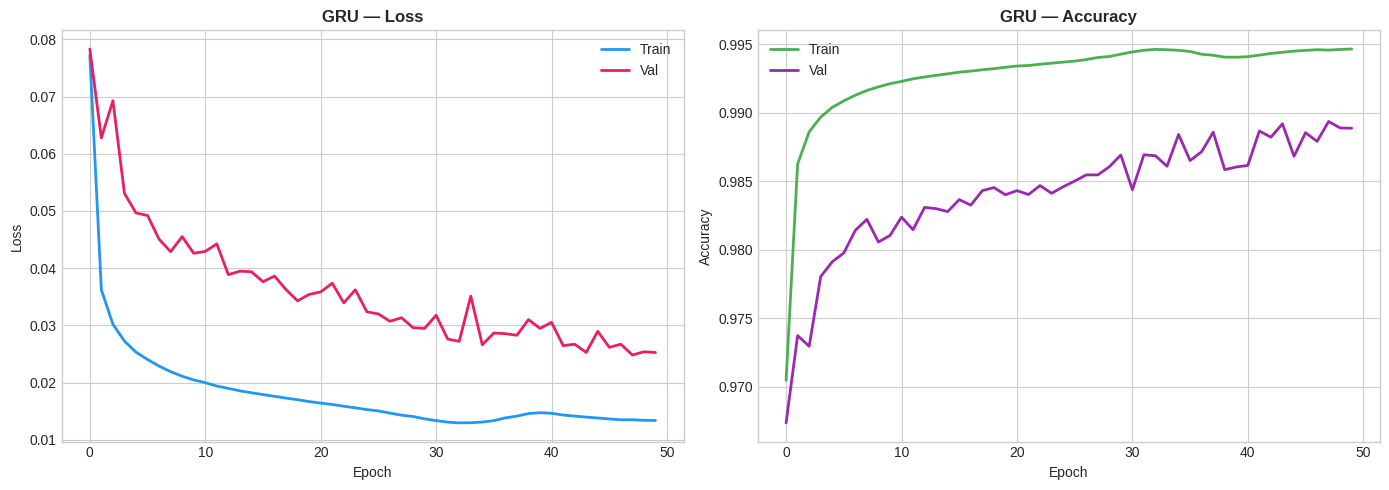

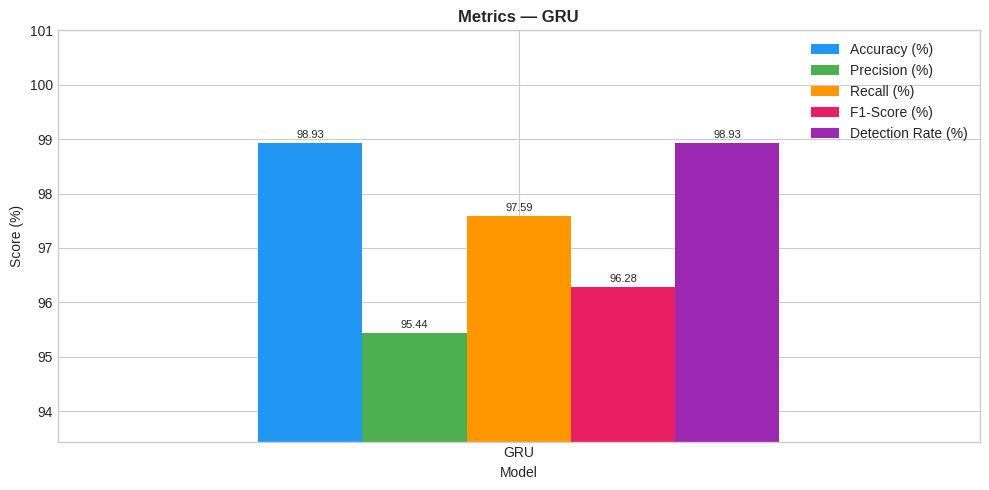

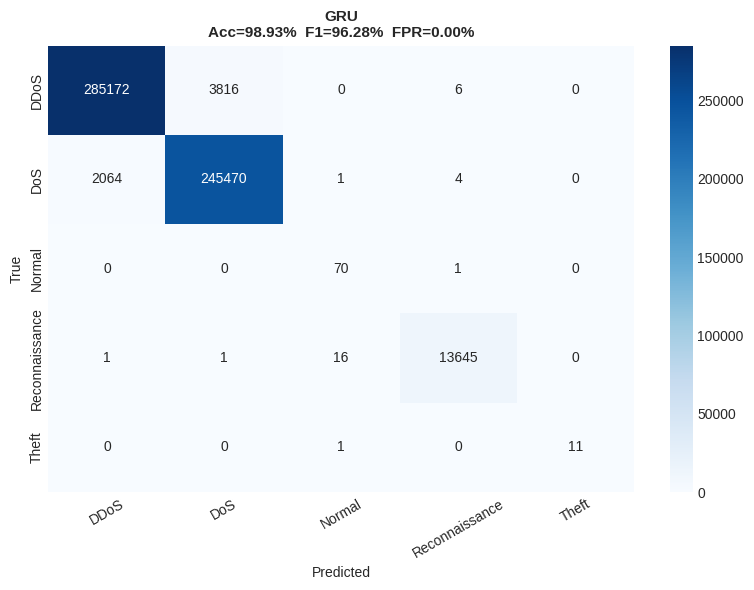

In [ ]:
# CELL 10: Visualizations — Single Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, classification_report

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

COLORS      = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
class_names = [str(c) for c in le.classes_]
h = all_histories[SINGLE_MODEL_NAME]
pred = all_predictions[SINGLE_MODEL_NAME]
m = all_results[SINGLE_MODEL_NAME]

# 10a. Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(h['loss'], label='Train', color=COLORS[0], lw=2)
ax1.plot(h['val_loss'], label='Val', color=COLORS[3], lw=2)
ax1.set_title(f'{SINGLE_MODEL_NAME} — Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.plot(h['accuracy'], label='Train', color=COLORS[1], lw=2)
ax2.plot(h['val_accuracy'], label='Val', color=COLORS[4], lw=2)
ax2.set_title(f'{SINGLE_MODEL_NAME} — Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
plt.tight_layout(); plt.show()

# 10b. ROC Curve (binary only)
if IS_BINARY:
    fig, ax = plt.subplots(figsize=(8, 6))
    fpr_v, tpr_v, _ = roc_curve(pred['y_true'], pred['y_proba'])
    ax.plot(fpr_v, tpr_v, color=COLORS[0], lw=2,
            label=f'{SINGLE_MODEL_NAME} (AUC={auc(fpr_v,tpr_v):.4f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curve — {SINGLE_MODEL_NAME}', fontweight='bold')
    ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

# 10c. Single-model metric bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bar_cols = ['Accuracy (%)','Precision (%)','Recall (%)','F1-Score (%)','Detection Rate (%)']
results_df[bar_cols].plot(kind='bar', ax=ax, color=COLORS[:5], width=0.65)
ax.set_ylabel('Score (%)'); ax.set_title(f'Metrics — {SINGLE_MODEL_NAME}', fontweight='bold')
ax.set_ylim([max(results_df[bar_cols].min().min()-2, 80), 101])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
plt.tight_layout(); plt.show()

# 10d. Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(pred['y_true'], pred['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=30)
ax.set_title(
    f'{SINGLE_MODEL_NAME}\nAcc={m["Accuracy (%)"]:.2f}%  F1={m["F1-Score (%)"]:.2f}%  FPR={m["FPR (%)"]:.2f}%',
    fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

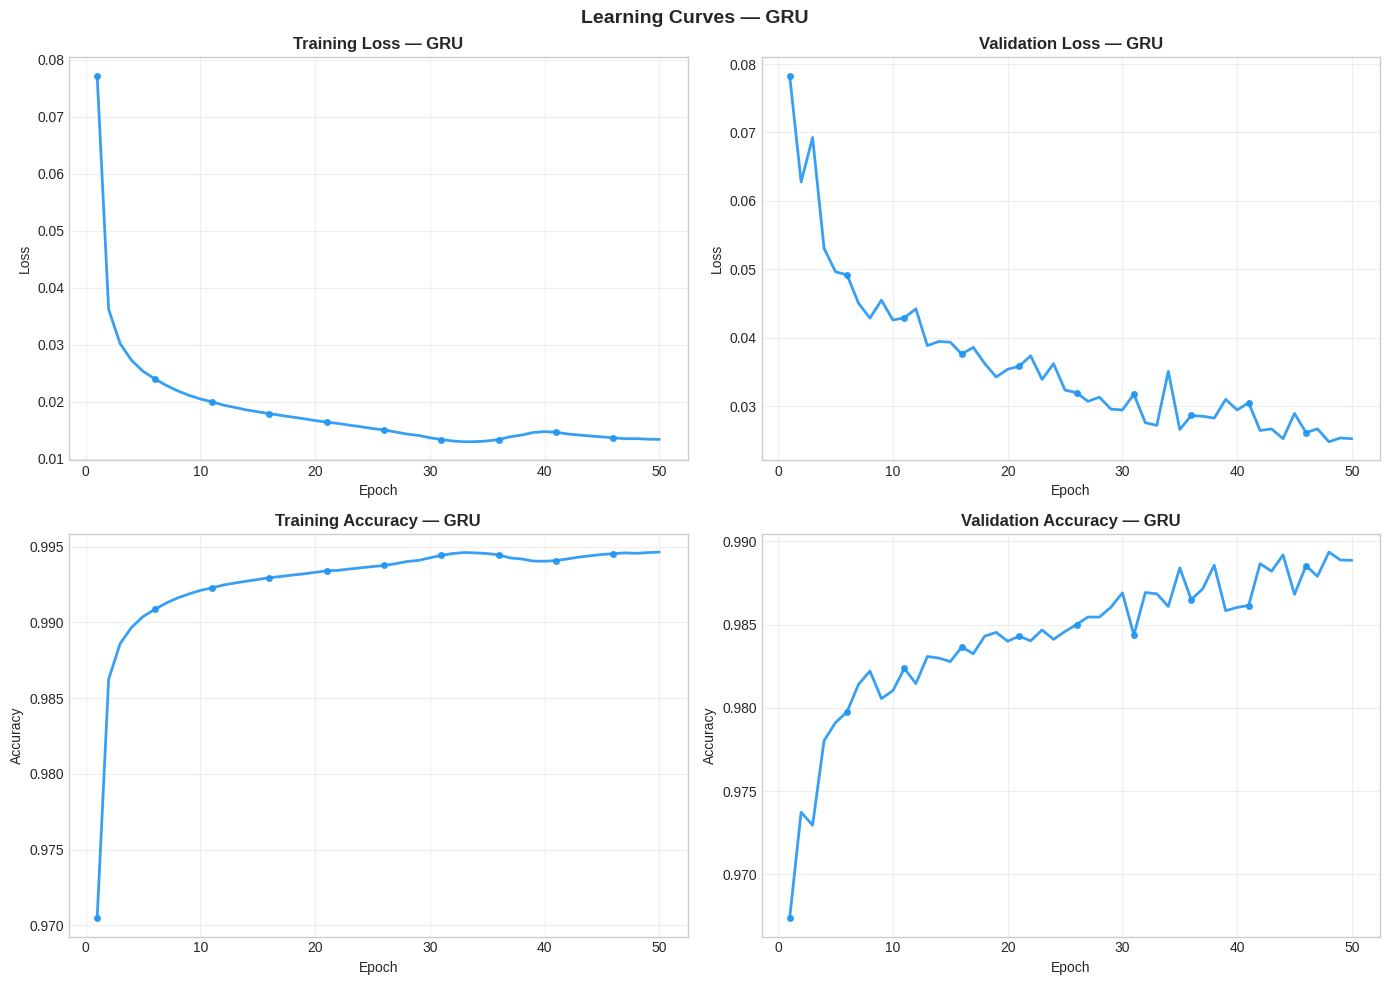

In [ ]:
# CELL 11: Learning Curves — Single Model
h = all_histories[SINGLE_MODEL_NAME]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for (metric_key, title, ylabel, ax) in [
    ('loss',         'Training Loss',       'Loss',     axes[0,0]),
    ('val_loss',     'Validation Loss',     'Loss',     axes[0,1]),
    ('accuracy',     'Training Accuracy',   'Accuracy', axes[1,0]),
    ('val_accuracy', 'Validation Accuracy', 'Accuracy', axes[1,1]),
]:
    ep = range(1, len(h[metric_key])+1)
    ax.plot(ep, h[metric_key], color='#2196F3', lw=2, marker='o',
            markersize=4, markevery=max(1, len(h[metric_key])//10), alpha=0.9)
    ax.set_title(f'{title} — {SINGLE_MODEL_NAME}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
plt.suptitle(f'Learning Curves — {SINGLE_MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Rebuilding GRU on CPU for SHAP...
Computing SHAP values — this may take a few minutes...


  0%|          | 0/200 [00:00<?, ?it/s]

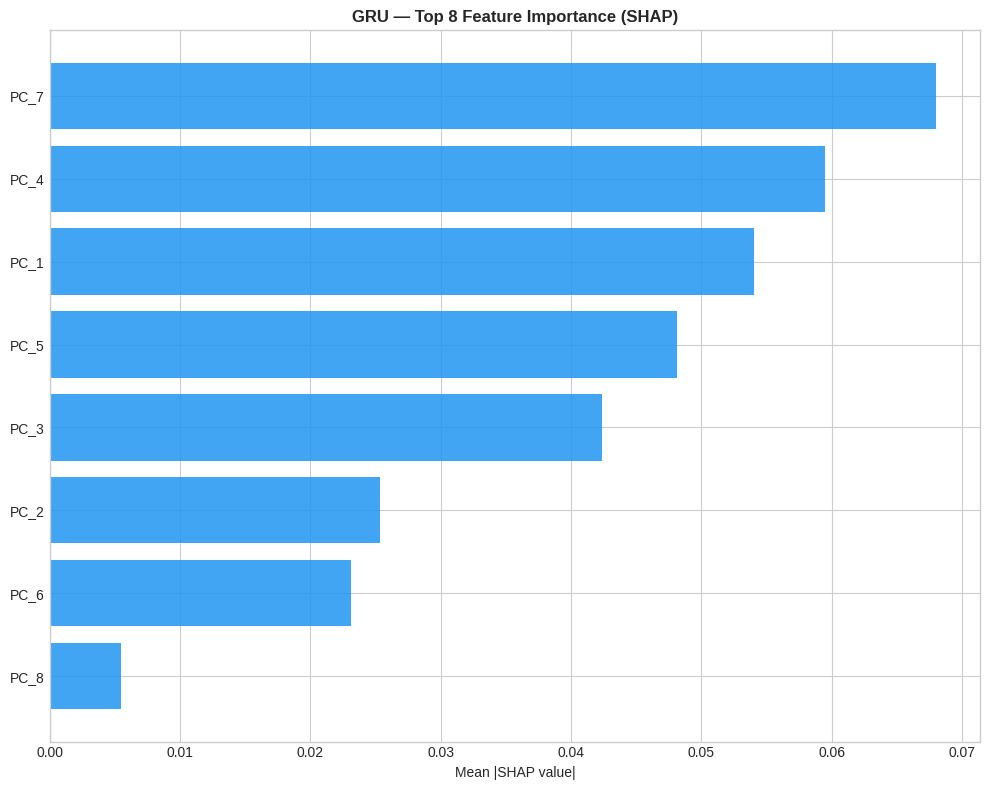


Top 10 features:
   1. PC_7: 0.0680
   2. PC_4: 0.0595
   3. PC_1: 0.0540
   4. PC_5: 0.0481
   5. PC_3: 0.0423
   6. PC_2: 0.0254
   7. PC_6: 0.0231
   8. PC_8: 0.0054


In [16]:
# CELL 12: SHAP Feature Importance — Single Model
import shap
import warnings
warnings.filterwarnings('ignore')

print(f'Rebuilding {SINGLE_MODEL_NAME} on CPU for SHAP...')
_cpu = jax.devices('cpu')[0]

with jax.default_device(_cpu):
    cpu_model = SINGLE_MODEL_BUILDER(INPUT_SHAPE, total_steps=1)
    cpu_model.set_weights(trained_models[SINGLE_MODEL_NAME].get_weights())

N_BACKGROUND = min(100, len(X_test))
N_EXPLAIN    = min(200, len(X_test))

background = np.asarray(X_test[:N_BACKGROUND], dtype=np.float32)
explain_X  = np.asarray(X_test[:N_EXPLAIN], dtype=np.float32)

def predict_fn_cpu(X_2d):
    X_2d = np.asarray(X_2d, dtype=np.float32)
    X_3d = X_2d.reshape(X_2d.shape[0], X_2d.shape[1], 1)
    with jax.default_device(jax.devices('cpu')[0]):
        proba = cpu_model.predict(X_3d, verbose=0)
    return proba.flatten() if IS_BINARY else proba

print('Computing SHAP values — this may take a few minutes...')
explainer   = shap.KernelExplainer(predict_fn_cpu, background)
shap_values = explainer.shap_values(explain_X, nsamples=100, l1_reg='aic')

# Feature names must be indexable with numpy arrays
pca_feature_names = np.asarray([f'PC_{i+1}' for i in range(X_test.shape[1])], dtype=object)

def reduce_shap_to_feature_importance(shap_obj, n_features):
    """
    Convert SHAP output into a 1D vector: mean absolute SHAP importance per feature.
    Handles:
      - list of arrays (multiclass KernelExplainer)
      - (samples, features)
      - (samples, features, classes)
      - (classes, samples, features)
      - (features,)
    """
    if isinstance(shap_obj, list):
        arrs = [np.abs(np.asarray(x, dtype=np.float64)) for x in shap_obj]
        arr = np.stack(arrs, axis=0)   # (classes, ... )
    else:
        arr = np.abs(np.asarray(shap_obj, dtype=np.float64))

    if arr.ndim == 1:
        if arr.shape[0] != n_features:
            raise ValueError(f"Expected 1D SHAP with {n_features} features, got shape {arr.shape}")
        return arr

    if arr.ndim == 2:
        # likely (samples, features)
        if arr.shape[1] == n_features:
            return arr.mean(axis=0)
        # fallback: (features, something)
        if arr.shape[0] == n_features:
            return arr.mean(axis=1)
        raise ValueError(f"Cannot identify feature axis in SHAP array of shape {arr.shape}")

    if arr.ndim == 3:
        # common cases:
        # (classes, samples, features) or (samples, features, classes)
        feature_axes = [ax for ax, size in enumerate(arr.shape) if size == n_features]
        if not feature_axes:
            raise ValueError(f"No axis matches n_features={n_features} in SHAP shape {arr.shape}")
        feat_axis = feature_axes[0]
        reduce_axes = tuple(ax for ax in range(arr.ndim) if ax != feat_axis)
        return arr.mean(axis=reduce_axes)

    raise ValueError(f"Unsupported SHAP output shape: {arr.shape}")

sv = reduce_shap_to_feature_importance(shap_values, len(pca_feature_names))
sv = np.asarray(sv, dtype=np.float64).reshape(-1)

top_k = min(20, len(sv))
sorted_idx   = np.argsort(sv)[::-1][:top_k]
top_features = pca_feature_names[sorted_idx].tolist()
top_shap     = sv[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top_features)), top_shap, color='#2196F3', alpha=0.85)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'{SINGLE_MODEL_NAME} — Top {top_k} Feature Importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

# Save for downstream aggregation
top_shap_features_df = pd.DataFrame({
    'feature': top_features,
    'mean_abs_shap': top_shap
})

print('\nTop 10 features:')
for i in range(min(10, len(top_features))):
    print(f'  {i+1:2d}. {top_features[i]}: {top_shap[i]:.4f}')

In [17]:
# ==========================================
# CELL B — SAVE ALL OUTPUTS FOR THIS RUN
# Place after final evaluation / SHAP / plots
# ==========================================

import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def _pick_first_global(names):
    for name in names:
        if name in globals() and globals()[name] is not None:
            return globals()[name]
    return None

def _json_safe(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return obj

# -------- pick common variables from notebook --------
model_obj = _pick_first_global(["final_model", "best_model", "model"])
history_obj = _pick_first_global(["history"])
metrics_obj = _pick_first_global(["final_metrics", "metrics_dict"])

# common prediction variable names
y_true_obj  = _pick_first_global(["y_true_eval", "y_true", "y_test_fit", "y_test"])
y_pred_obj  = _pick_first_global(["y_pred"])
y_proba_obj = _pick_first_global(["y_proba", "y_prob", "y_probs"])

# class names if present
class_names = None
if "le" in globals():
    try:
        class_names = [str(c) for c in le.classes_]
    except Exception:
        class_names = None

# -------- save model summary --------
if model_obj is not None:
    summary_lines = []
    model_obj.summary(print_fn=lambda x: summary_lines.append(x))
    with open(os.path.join(ARTIFACT_DIR, "model_summary.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(summary_lines))

# -------- save current/final weights --------
if model_obj is not None:
    model_obj.save_weights(os.path.join(ARTIFACT_DIR, f"{MODEL_SLUG}_final.weights.h5"))

# -------- save best checkpoint if notebook created one --------
ckpt_candidate = _pick_first_global(["ckpt_path"])
if isinstance(ckpt_candidate, str) and os.path.exists(ckpt_candidate):
    shutil.copy2(ckpt_candidate, os.path.join(ARTIFACT_DIR, os.path.basename(ckpt_candidate)))

# also copy anything in models_checkpoint if present
if os.path.isdir("models_checkpoint"):
    for fname in os.listdir("models_checkpoint"):
        src = os.path.join("models_checkpoint", fname)
        if os.path.isfile(src):
            shutil.copy2(src, os.path.join(ARTIFACT_DIR, fname))

# -------- save training history --------
if history_obj is not None and hasattr(history_obj, "history"):
    history_df = pd.DataFrame(history_obj.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
    history_df.to_csv(os.path.join(RUN_DIR, "history.csv"), index=False)

# -------- save metrics --------
if metrics_obj is None and "results_df_now" in globals():
    try:
        metrics_obj = results_df_now.iloc[0].to_dict()
    except Exception:
        pass

if metrics_obj is None and "results_df" in globals():
    try:
        metrics_obj = results_df.iloc[0].to_dict()
    except Exception:
        pass

if metrics_obj is not None:
    metrics_clean = {str(k): _json_safe(v) for k, v in dict(metrics_obj).items()}
    with open(os.path.join(RUN_DIR, "metrics.json"), "w", encoding="utf-8") as f:
        json.dump(metrics_clean, f, indent=2)

# -------- save predictions --------
if y_true_obj is not None:
    np.save(os.path.join(RUN_DIR, "y_true.npy"), np.asarray(y_true_obj))
if y_pred_obj is not None:
    np.save(os.path.join(RUN_DIR, "y_pred.npy"), np.asarray(y_pred_obj))
if y_proba_obj is not None:
    np.save(os.path.join(RUN_DIR, "y_proba.npy"), np.asarray(y_proba_obj))

# -------- save confusion matrix + classification report --------
if y_true_obj is not None and y_pred_obj is not None:
    y_true_arr = np.asarray(y_true_obj)
    y_pred_arr = np.asarray(y_pred_obj)

    cm = confusion_matrix(y_true_arr, y_pred_arr)
    np.save(os.path.join(RUN_DIR, "confusion_matrix.npy"), cm)
    pd.DataFrame(cm).to_csv(os.path.join(RUN_DIR, "confusion_matrix.csv"), index=False)

    report_text = classification_report(
        y_true_arr,
        y_pred_arr,
        target_names=class_names,
        digits=4
    )
    with open(os.path.join(RUN_DIR, "classification_report.txt"), "w", encoding="utf-8") as f:
        f.write(report_text)

# -------- save SHAP outputs if present --------
# Arrays
for var_name in ["shap_values", "shap_importance", "mean_abs_shap"]:
    if var_name in globals() and globals()[var_name] is not None:
        try:
            np.save(os.path.join(RUN_DIR, f"{var_name}.npy"), np.asarray(globals()[var_name]))
        except Exception:
            pass

# DataFrames
for var_name in ["shap_df", "top_shap_features_df", "shap_feature_importance_df"]:
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        globals()[var_name].to_csv(os.path.join(RUN_DIR, f"{var_name}.csv"), index=False)

# feature names
feature_names_obj = _pick_first_global(["feature_names", "selected_feature_names"])
if feature_names_obj is not None:
    with open(os.path.join(RUN_DIR, "feature_names.json"), "w", encoding="utf-8") as f:
        json.dump([str(x) for x in list(feature_names_obj)], f, indent=2)

# -------- save all open matplotlib figures --------
for fig_num in plt.get_fignums():
    fig = plt.figure(fig_num)
    fig.savefig(
        os.path.join(FIG_DIR, f"figure_{fig_num}.png"),
        dpi=200,
        bbox_inches="tight"
    )

# -------- save metadata --------
metadata = {
    "model_name": MODEL_NAME,
    "model_slug": MODEL_SLUG,
    "run_timestamp": RUN_TS,
    "python_version": sys.version,
    "platform": platform.platform(),
    "cwd": os.getcwd(),
}

# JAX / accelerator info if available
try:
    import jax
    metadata["jax_devices"] = [str(d) for d in jax.devices()]
except Exception:
    pass

# precision policy if available
try:
    import keras
    metadata["precision_policy"] = keras.mixed_precision.global_policy().name
except Exception:
    pass

with open(os.path.join(RUN_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved run bundle to: {RUN_DIR}")

Saved run bundle to: results/gru/20260401_061855


In [18]:
# ==========================================
# CELL C — ZIP + DOWNLOAD THIS RUN TO YOUR PC
# Place as the last cell in each training notebook
# ==========================================

import os
import shutil
from google.colab import files

zip_base = f"{MODEL_SLUG}_{RUN_TS}"
zip_path = shutil.make_archive(zip_base, "zip", RUN_DIR)

print("Created:", zip_path)
files.download(zip_path)

Created: /content/gru_20260401_061855.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Single-model notebook

Generated from v14. This variant trains **GRU** only.

### Notes

- Single selected model: **GRU**
- Builder: `build_gru`
- Derived from the latest v14 paper-faithful notebook.